**Libraries**

In [1]:
import numpy as np
from numpy.typing import NDArray

from bloodmoon.mask import CodedMaskCamera
import darksun as ds

import wmsims as wm

In [2]:
# plotting setup
import matplotlib.pyplot as plt
plt.style.use('dark_background')

**Coded-mask cameras mask design and pointings setup**

In [3]:
base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations"
#base_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

wfm: CodedMaskCamera = wm.init_cameras_mask(f"{base_path}/{MASK_FITS}")

In [4]:
SAVE_SKYFIELD: bool = False
SAVE_CATALOGUE: bool = False

SAVE_TO: str = '/home/edoardo/Desktop'
#SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'

In [5]:
from functools import lru_cache

from bloodmoon.coords import angle2shift
from bloodmoon.optim import _detector_footprint_cached
from bloodmoon.optim import _mask_pattern_projection


@lru_cache(maxsize=1)
def camera_area_unit(camera: CodedMaskCamera) -> float:
    """
    Computes the detector unit area value in [cm^2], corrected for
    the camera layers and detectors efficiency photons absorption.
    """
    # LEM-X camera layers and detector efficiency correction factors
    # here we consider the absorption action of (photons absorption @ 8keV):
    #   - 12.5um Kapton layer (coded-mask camera MLI)
    #   - 25um Be layer (micro-meteoroid filter)
    #   - 300nm Al layers (total, between MLI and micro-meteoroid filter)
    #   - detector dead layers
    #   - SDD QE (i.e., detector absrp efficiency)
    # https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/Effective_area_and_Sens_2D.ipynb
    corrs: dict[str, float] = {
        'Kapton_layer': 0.98945,
        'Be_layer': 0.99527,
        'Al_layer': 0.99614,
        'dead_layers': 0.974,
        'QE': 0.999,
    }
    qe_factor: float = np.prod(np.array(list(corrs.values())))
    # pixel area in [cm^2]
    pixel_area: float = (
        1e-2 * camera.specs.mask_deltax * camera.specs.mask_deltay / np.prod(camera.upscale_f)
    )
    return pixel_area * qe_factor


def get_effective_area(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    vignetting: bool = True,
) -> float:
    """Computes source effective area from detector in [cm^2]."""
    # mask pattern projection WTO detector sp. res.
    sg = _mask_pattern_projection(
        camera, shift_x, shift_y, vignetting, False,
    )
    # extract detector
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = sg[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    return detector.sum() * camera_area_unit(camera)


def verbose(
    flux: float,
    exposure: float,
    coords: tuple[float, float],
    significance: float,
    sigmas: float,
) -> None:
    """Prints out info on source SNR and camera sensitivity."""
    print(
        f'Significance for {flux}Crab in {exposure}s at ({coords[0]}, {coords[1]})deg: {significance:.3f}\n'
        f'Source flux at {sigmas} sigma: {sigmas * flux / significance:.3f} Crab\n'
        #f'...: {sigmas / snr:.5f}\n'
        #f'Camera Sensitivity at {sigmas} sigma: {crab / (sigmas / snr):.0f} mCrab\n'
    )
    return None

In [6]:
def compute_effective_area_map(
    camera: CodedMaskCamera,
    shift_x: NDArray,
    shift_y: NDArray,
    vignetting: bool = True,
) -> float | NDArray:
    """Computes source effective area on coded-mask camera detector."""
    eff_area: NDArray = np.zeros((len(shift_y), len(shift_x)))
    for i, sy in enumerate(shift_y):
        for j, sx in enumerate(shift_x):
            eff_area[i, j] = get_effective_area(camera, sx, sy, vignetting)
    return eff_area

thetas_x, thetas_y = (
    np.linspace(0.0, 45.0, 46),
    np.linspace(0.0, 45.0, 46),
)
shifts_x, shifts_y = map(
    lambda x: angle2shift(wfm, x),
    (thetas_x, thetas_y),
)

In [7]:
eff_area_map: NDArray = compute_effective_area_map(
    camera=wfm,
    shift_x=shifts_x,
    shift_y=shifts_y,
)

## USING BULK MASK with 0.0 mm cover ##


In [8]:
Y, X = len(shifts_y), len(shifts_x)
tot_eff_area: NDArray = np.zeros((2 * Y - 1, 2 * X - 1))

tot_eff_area[-Y:, -X:] = eff_area_map                  # top-right
tot_eff_area[-Y:, :X] = np.flip(eff_area_map, 1)       # top-left
tot_eff_area[:Y, X - 1:] = np.flip(eff_area_map, 0)    # bottom-right
tot_eff_area[:Y, :X] = np.flip(eff_area_map, (0, 1))   # bottom-left

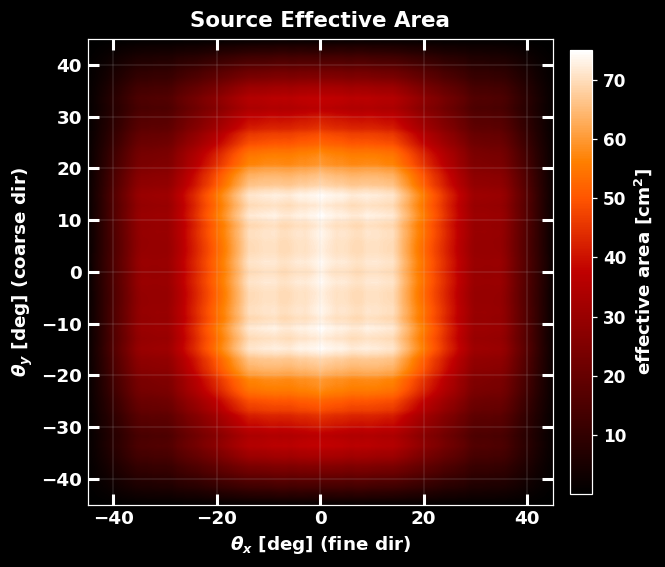

In [9]:
ds.image_plot(
    ds.map4image(
        img=tot_eff_area,
        title='Source Effective Area',
        xlabel='$\\theta_{x}$ [deg] (fine dir)',
        ylabel='$\\theta_{y}$ [deg] (coarse dir)',
        cbarlabel='effective area [cm$^{2}$]',
        img_kwargs={
            'cmap': 'gist_heat',
            'interpolation': 'bilinear',
            'extent': [-45, 45, -45, 45],
        }
    ),
    save_to=ds.savefig_to(SAVE_TO, 'sourceEffArea', overwrite=True),
)

In [ ]:
from typing import Any

from bloodmoon.coords import shift2pos
from bloodmoon.optim import model_shadowgram
from bloodmoon.mask import solid_angle_profile
from bloodmoon.mask import decode, variance, snratio


def get_source_significance(
    camera: CodedMaskCamera,
    flux: float,
    exposure: float,
    shift_x: float,
    shift_y: float,
    vignetting: bool = True,
    psfy: bool = True,
) -> float:
    """
    Computes the significance of a single source with sky background.

    Flux is in [Crab], exposure in [s].
    """
    # flux values for LEM-X single coded-mask camera, from WM sims
    SETUP: dict[str, Any] = {
        'bkg_instr_fluence': 6.3799,    # bkg instr. flux [ph/cm2/s] (for on-axis eff area)
        'crab_instr_fluence': 2.5737,   # 1 Crab instr. flux [ph/cm2/s] (for on-axis eff area)
    }

    # observed fluences (cts / detector unit area)
    bkg_fluence: float = SETUP['bkg_instr_fluence'] * exposure
    source_fluence: float = flux * SETUP['crab_instr_fluence'] * exposure

    # detector image: dome-shaped bkg profile + source
    on_axis_eff_area: float = get_effective_area(camera, 0.0, 0.0, vignetting)
    omega: NDArray = solid_angle_profile(camera)
    bkg: NDArray = (
        bkg_fluence * on_axis_eff_area * omega / omega.sum()
    )

    off_axis_eff_area: float = get_effective_area(camera, shift_x, shift_y, vignetting)
    counts: float = source_fluence * off_axis_eff_area
    source_sg: NDArray = model_shadowgram(
        camera, shift_x, shift_y, vignetting, psfy,
    )

    detector: NDArray = bkg + source_sg * counts

    # compute significance
    sky: NDArray = decode(camera, detector)
    varmap: NDArray = variance(camera, detector)
    snrmap: NDArray = snratio(sky, varmap)
    pos: tuple[int, int] = shift2pos(camera, shift_x, shift_y)

    return snrmap[*pos]

In [11]:
theta_x, theta_y = 0.0, 0.0   # [deg]
flux: float = 1.0               # [Crab]
exposure: float = 1e3           # [s]
sigmas: float = 5.0

shift_x, shift_y = map(
    lambda x: angle2shift(wfm, x),
    (theta_x, theta_y),
)
snr: float = get_source_significance(
    camera=wfm,
    flux=flux,
    exposure=exposure,
    shift_x=shift_x,
    shift_y=shift_y,
)
verbose(
    flux=flux,
    exposure=exposure,
    coords=(theta_x, theta_y),
    significance=snr,
    sigmas=sigmas,
)

Total bkg counts: 465402.71227731317
Total source counts: 187746.98045237715

Significance for 1.0Crab in 1000.0s at (0.0, 0.0)deg: 232.362
Source flux at 5.0 sigma: 0.022 Crab



In [12]:
get_source_significance(
    camera=wfm,
    flux=flux,
    exposure=exposure,
    shift_x=shift_x,
    shift_y=shift_y,
    vignetting=False,
    psfy=False,
)

Total bkg counts: 465402.71227731317
Total source counts: 187746.98045237715



np.float64(254.12620453797186)